# 📡 5.2 1D-CNN Classification Model con Gated Pooling

Este notebook explora una arquitectura basada en **Redes Neuronales Convolucionales de una dimensión (1D-CNN)** con **Gated Pooling** para la clasificación de los embeddings de proteínas generados por ProtFlash. A diferencia del MLP gated, la CNN busca identificar patrones locales o “motivos” a lo largo de la secuencia, mientras que el `GatedPooler` pondera dinámicamente la contribución de cada residuo.

---

## 📋 Descripción general

El modelo recibe tres entradas:
- `X`: embeddings por residuo, con forma `(B, L, 768)`.
- `G`: embedding global/contextual de la secuencia, con forma `(B, 768)`.
- `M`: máscara binaria, con forma `(B, L)`, usada para ignorar posiciones de padding.

La arquitectura `GatedConv1DClassifier`:
1. Calcula gates por residuo mediante `GatedPooler` y genera un embedding agregado `E`.
2. Procesa `X` con bloques `Conv1d` + `BatchNorm1d` + `GELU` + `Dropout1d`, aplicando la máscara `M`.
3. Genera representaciones globales mediante *max pooling* enmascarado y *average pooling*.
4. Concatena las características convolucionales, el embedding global `G` y el embedding agregado `E`.
5. Procesa la representación combinada con un MLP y finaliza con una capa lineal de logits.

---

## 🛠️ Funcionalidades principales

1. **Arquitectura del modelo**
   - Bloques convolucionales 1D con `Conv1d`, `BatchNorm1d`, `GELU` y `Dropout1d`.
   - `Gated Pooling` aprendido para agregar la información por residuo.
   - Pooling global mediante *max pooling* y *average pooling*.
   - Combinación con el embedding global para la clasificación.

2. **Entrenamiento y optimización**
   - Optimizador `AdamW` con *weight decay*.
   - Función de pérdida `FocalLoss` para manejar el desbalance de clases.
   - `ReduceLROnPlateau` para ajustar la tasa de aprendizaje.
   - *Early stopping* basado en la pérdida de validación.

3. **Búsqueda de hiperparámetros**
   - Evaluación de tres configuraciones: `Gated_CNN_Small`, `Gated_CNN_Medium` y `Gated_CNN_Large`.
   - Variación de canales convolucionales, tamaños de kernel, capas MLP, *dropout* y tasa de aprendizaje.

4. **Monitoreo y registro**
   - Registro por época de pérdida de entrenamiento/validación, accuracy, F1, MCC, ROC-AUC y PR-AUC.
   - Guardado automático del mejor modelo según la menor pérdida de validación.
   - Exportación de checkpoints, métricas y curvas de entrenamiento.

## 📦 Importación de librerías y entorno

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)

import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de rutas e hiperparámetros CNN

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/new-final-dataset")
OUT_DIR = Path("/kaggle/working/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT  = DATA_DIR / "train_dataset.pt"
VAL_PT    = DATA_DIR / "val_dataset.pt"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 32
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
INPUT_DIM   = 768      # Embeddings dimension
L_MAX       = 100

# ========== ARCHITECTURES ==========
ARCHITECTURES = [
    {
        "name": "Gated_CNN_Small",
        "conv_channels": [128, 64],
        "kernel_sizes": [3, 5],
        "mlp_hidden": [128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_CNN_Medium",
        "conv_channels": [256, 128],
        "kernel_sizes": [3, 5],
        "mlp_hidden": [128],
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_CNN_Large",
        "conv_channels": [512, 256, 128],
        "kernel_sizes": [3, 5, 5],
        "mlp_hidden": [256, 128],
        "dropout": 0.4,
        "lr": 5e-4,  # Learning rate ligeramente menor para una red más grande
        "weight_decay": 1e-4,
    },
]

print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: hidden={cfg['mlp_hidden']}, dropout={cfg['dropout']}")

Architectures to compare: 3
  - Gated_CNN_Small: hidden=[128], dropout=0.3
  - Gated_CNN_Medium: hidden=[128], dropout=0.4
  - Gated_CNN_Large: hidden=[256, 128], dropout=0.4


## 🖥️ Semilla para reproducibilidad y detección de dispositivo

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 📂 Definición de la clase `AMPDataset`

In [4]:
class AMPDataset(Dataset):
    """
    Dataset for training the AMP classifier with Gated Pooling.

    Returns:
        X:     torch.FloatTensor (L_max, 768)    — ProtFlash embeddings
        G:     torch.FloatTensor (768,)          — Global/CLS context embedding
        M:     torch.FloatTensor (L_max,)        — binary mask
        y:     torch.FloatTensor (1,)            — label
    """
    def __init__(self, X, G, M, labels):
        self.X = torch.from_numpy(X).float()          # (N, 100, 768)
        self.G = torch.from_numpy(G).float()          # (N, 768)
        self.M = torch.from_numpy(M).float()          # (N, 100)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (100, 768)
            "G": self.G[idx],           # (768,)
            "M": self.M[idx],           # (100,)
            "y": self.y[idx]            # (1,)
        }

## 💾 Función de carga de datasets pre-serializados

In [5]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de entrenamiento y validación

In [6]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13766 muestras
   val_ds  : 4128 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   y: str = 'y'


## 🤝 Función de colación (`collate_fn`)

In [7]:
def collate_fn(batch):
    if isinstance(batch[0], dict):
        embeddings = torch.stack([item['X'] for item in batch], dim=0)
        globals_emb = torch.stack([item['G'] for item in batch], dim=0) 
        masks       = torch.stack([item['M'] for item in batch], dim=0)
        labels      = torch.stack([item['y'] for item in batch], dim=0)
    else:
        raise TypeError(f"Batch fallido")
    return embeddings, globals_emb, masks, labels

## 🚚 Creación de DataLoaders

In [8]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✅ Batches: train={len(train_loader)}, val={len(val_loader)}")

X_b, G_b, M_b, y_b = next(iter(train_loader))
print(f"   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)}")


✅ Batches: train=431, val=129
   ✅ X_b: (32, 100, 768) | G_b: (32, 768)


## 🧩 Capa `GatedPooler`

In [9]:
class GatedPooler(nn.Module):
    """
    Gated pooling diferenciable.

    Input:
        - X: (B, L, D) embeddings por residuo
        - M: (B, L) máscara binaria

    Output:
        - E: (B, D) embedding agregado por secuencia
    """

    def __init__(self, input_dim: int):
        super().__init__()

        # Gate aprendido desde el embedding de cada residuo
        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        # Proyección opcional
        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        # X: (B, L, D)
        # M: (B, L)

        gates = self.gating_mlp(X) * M.unsqueeze(-1)   # (B, L, 1)

        weighted = gates * self.proj(X)

        # Media ponderada
        return weighted.sum(dim=1) / (gates.sum(dim=1) + 1e-8)

    def get_gates(self, X: torch.Tensor, M: torch.Tensor):
        gates = self.gating_mlp(X)
        gates = gates * M.unsqueeze(-1)
        return gates

## 🏗️ Arquitectura `GatedConv1DClassifier` y Verificación

In [10]:
class GatedConv1DClassifier(nn.Module):
    """
    1D-CNN classifier con Gated Pooling.
    """

    def __init__(
        self,
        input_dim: int,
        conv_channels: List[int],
        kernel_sizes: List[int],
        mlp_hidden: List[int],
        dropout: float = 0.3,
    ):
        super().__init__()

        # Gated Pooling aprendido (sin AAontology)
        self.pooler = GatedPooler(input_dim=input_dim)

        self.convs = nn.ModuleList()
        in_channels = input_dim

        for out_channels, k_size in zip(conv_channels, kernel_sizes):
            self.convs.append(
                nn.Sequential(
                    nn.Conv1d(
                        in_channels,
                        out_channels,
                        kernel_size=k_size,
                        padding="same",
                    ),
                    nn.BatchNorm1d(out_channels),
                    nn.GELU(),
                    nn.Dropout1d(dropout),
                )
            )
            in_channels = out_channels

        cnn_out_dim = in_channels * 2  # MaxPool + AvgPool
        clf_in_dim = cnn_out_dim + input_dim + input_dim  # CNN + Global + Gated

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(
        self,
        X: torch.Tensor,
        G: torch.Tensor,
        M: torch.Tensor,
    ) -> torch.Tensor:

        # Embedding local mediante gated pooling
        E = self.pooler(X, M)

        # (B,L,D) -> (B,D,L)
        x_cnn = X.transpose(1, 2)

        for conv in self.convs:
            x_cnn = conv(x_cnn)
            x_cnn = x_cnn * M.unsqueeze(1)

        mask_bool = M.unsqueeze(1).bool()

        # Max pooling ignorando padding
        x_cnn_max = x_cnn.masked_fill(~mask_bool, -1e9)
        max_pooled = F.adaptive_max_pool1d(x_cnn_max, 1).squeeze(-1)

        # Average pooling real
        sum_pooled = x_cnn.sum(dim=-1)
        lengths = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = sum_pooled / lengths

        cnn_features = torch.cat([max_pooled, avg_pooled], dim=1)

        combined = torch.cat([cnn_features, G, E], dim=1)

        x = self.mlp(combined)

        return self.classifier(x)

    def get_gates(
        self,
        X: torch.Tensor,
        M: torch.Tensor,
    ) -> torch.Tensor:
        """Devuelve los gates por residuo."""

        return self.pooler.get_gates(X, M).squeeze(-1)


def build_cnn_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedConv1DClassifier(
        input_dim,
        config["conv_channels"],
        config["kernel_sizes"],
        config["mlp_hidden"],
        config["dropout"],
    )

# ========== SANITY CHECK ==========
_test_model = build_cnn_model(ARCHITECTURES[0], INPUT_DIM)

_test_X = torch.randn(2, L_MAX, INPUT_DIM)
_test_G = torch.randn(2, INPUT_DIM)

_test_M = torch.ones(2, L_MAX)
_test_M[0, 50:] = 0

with torch.no_grad():
    _test_out = _test_model(_test_X, _test_G, _test_M)
    _test_gates = _test_model.get_gates(_test_X, _test_M)

_n = sum(p.numel() for p in _test_model.parameters())

print(
    f"Sanity check ({ARCHITECTURES[0]['name']}): "
    f"params={_n:,}, "
    f"output shape={_test_out.shape}, "
    f"gates shape={_test_gates.shape}"
)

del _test_model, _test_X, _test_G, _test_M, _test_out, _test_gates

Sanity check (Gated_CNN_Small): params=1,239,106, output shape=torch.Size([2, 1]), gates shape=torch.Size([2, 100])


## 📐 Helper: `sigmoid_np`

In [11]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [12]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    logits_list, y_list = [], []
    for Xb, Gb, Mb, yb in loader:
        logits = model(Xb.to(device), Gb.to(device), Mb.to(device))
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
    return sigmoid_np(np.concatenate(logits_list)), np.concatenate(y_list)

## 📏 Cálculo de Métricas de Clasificación

In [13]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [15]:
def train_model(config, input_dim, train_loader, val_loader, device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    seed_everything(SEED)
    model = build_cnn_model(config, input_dim).to(device)
    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": [], "val_roc_auc": []}
    best_val_loss = float("inf")
    best_state = None; best_epoch = 0; no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss, n = 0.0, 0
        for Xb, Gb, Mb, yb in train_loader:
            Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb, Gb, Mb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)
        train_loss /= n

        model.eval()
        val_loss, n = 0.0, 0
        with torch.no_grad():
            for Xb, Gb, Mb, yb in val_loader:
                Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
                loss = criterion(model(Xb, Gb, Mb), yb)
                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)
        val_loss /= n
        scheduler.step(val_loss)
        
        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)
        
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])
        history["val_roc_auc"].append(v_met["roc_auc"])

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")
        if no_improve >= patience: break

    model.load_state_dict(best_state)
    return {"model": model, "history": history, "best_epoch": best_epoch, "best_val_loss": best_val_loss}

## 🔬 Ejecución Secuencial de Arquitecturas

In [16]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    
    n_params = sum(p.numel() for p in res["model"].parameters())
    
    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({"model_name": config["name"], "state_dict": res["model"].state_dict(), "config": config, "input_dim": INPUT_DIM}, ckpt_path)
    
    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "model": res["model"],
        "config": config,
        "history": res["history"],
        "training_time_sec": 0.0,
    })

    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_roc_auc={v_metrics.get('roc_auc', 0.0):.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)


--- Entrenando Gated_CNN_Small ---
E01 | TL: 0.0614 | VL: 0.0542 | Val MCC: 0.7703 | B_ep: 1
E02 | TL: 0.0523 | VL: 0.0524 | Val MCC: 0.7757 | B_ep: 2
E03 | TL: 0.0490 | VL: 0.0510 | Val MCC: 0.7803 | B_ep: 3
E04 | TL: 0.0456 | VL: 0.0504 | Val MCC: 0.7948 | B_ep: 4
E05 | TL: 0.0433 | VL: 0.0532 | Val MCC: 0.7702 | B_ep: 4
E06 | TL: 0.0405 | VL: 0.0550 | Val MCC: 0.7890 | B_ep: 4
E07 | TL: 0.0373 | VL: 0.0529 | Val MCC: 0.7763 | B_ep: 4
E08 | TL: 0.0358 | VL: 0.0522 | Val MCC: 0.8039 | B_ep: 4
E09 | TL: 0.0339 | VL: 0.0542 | Val MCC: 0.7880 | B_ep: 4
E10 | TL: 0.0315 | VL: 0.0529 | Val MCC: 0.7934 | B_ep: 4
E11 | TL: 0.0236 | VL: 0.0616 | Val MCC: 0.7992 | B_ep: 4
E12 | TL: 0.0213 | VL: 0.0659 | Val MCC: 0.8040 | B_ep: 4
E13 | TL: 0.0203 | VL: 0.0716 | Val MCC: 0.8095 | B_ep: 4
E14 | TL: 0.0171 | VL: 0.0703 | Val MCC: 0.7954 | B_ep: 4
E15 | TL: 0.0162 | VL: 0.0681 | Val MCC: 0.7918 | B_ep: 4
E16 | TL: 0.0132 | VL: 0.0932 | Val MCC: 0.8151 | B_ep: 4

  ✅ Gated_CNN_Small: params=1,239,1

## 📊 Tabla Resumen y Ranking de Modelos

In [17]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
        "Time (s)": round(r["training_time_sec"], 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("ARCHITECTURE COMPARISON (sorted by Val MCC)")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)

summary_df.to_csv(OUT_DIR / "cnn_architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


ARCHITECTURE COMPARISON (sorted by Val MCC)
              Model   Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC  Time (s)
0   Gated_CNN_Large  3183490           8  0.047152  0.906492  0.894651  0.815590     0.960963    0.966240       0.0
1   Gated_CNN_Small  1239106           4  0.050371  0.895107  0.879956  0.794791     0.956541    0.961564       0.0
2  Gated_CNN_Medium  1673858           4  0.048629  0.893411  0.881274  0.787736     0.956786    0.962077       0.0

Saved

🏆 Best model: Gated_CNN_Large


## 📈 Visualización: Curvas de Entrenamiento Individuales

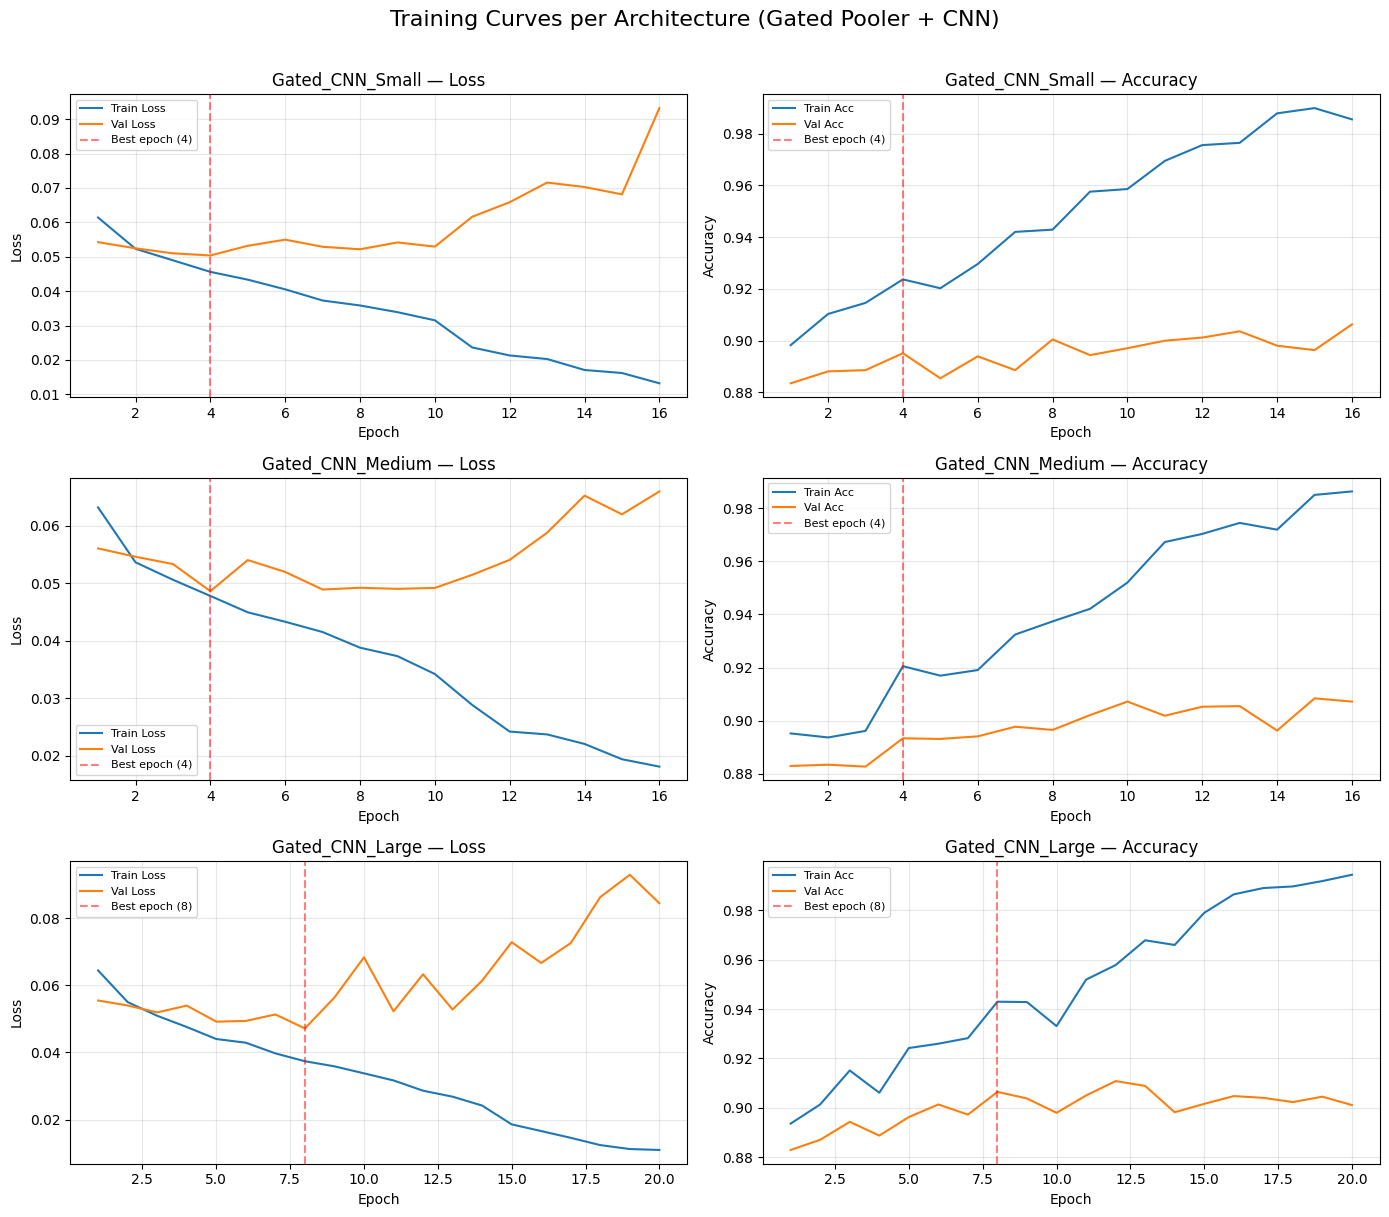

Saved: /kaggle/working/training_curves_individual.png


In [18]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Gated Pooler + CNN)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Curvas comparativas conjuntas

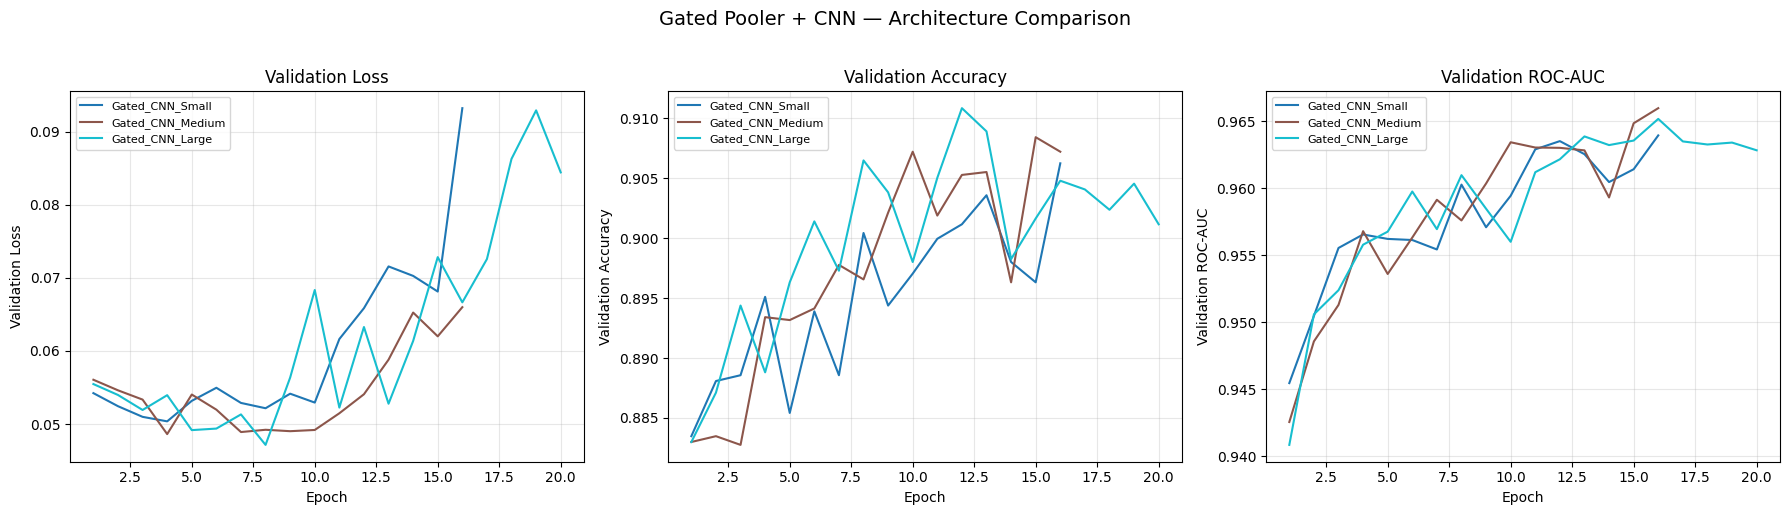

Saved: /kaggle/working/training_curves_comparison.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_roc_auc"], label=r["name"], color=colors[idx], linewidth=1.5)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Validation ROC-AUC"); axes[2].set_title("Validation ROC-AUC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler + CNN — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

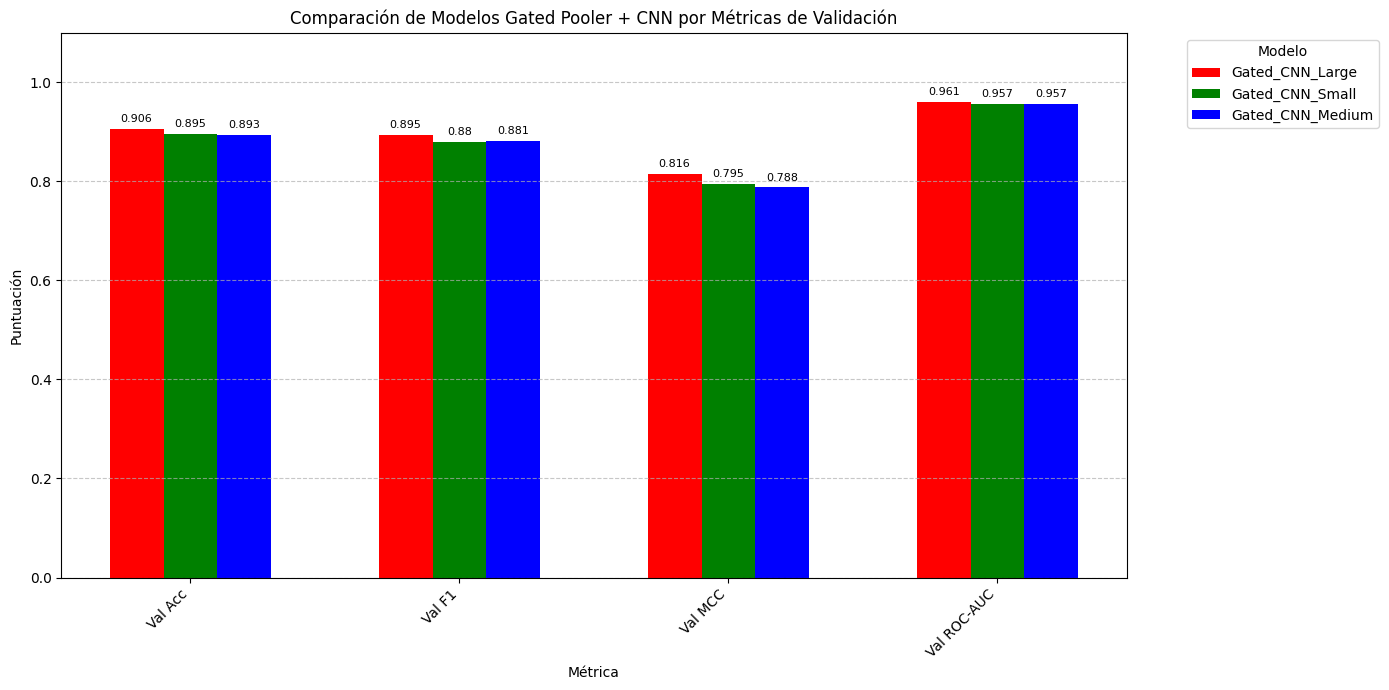

Saved: /kaggle/working/model_metrics_comparison_bar_chart.png


In [20]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['red', 'green', 'blue']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler + CNN por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [21]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": res["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "training_time_sec": best_result["training_time_sec"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")

🏆 Best model: Gated_CNN_Large
   Parameters: 3,183,490
   Best epoch: 8
   Val loss:   0.047152

Saved:
  Checkpoint:    /kaggle/working/best_model_final.pth
  Training log:  /kaggle/working/best_model_training_log.csv
  Val metrics:   /kaggle/working/best_model_val_metrics.json


## 🏆 Conclusión: el mejor modelo

Tras completar el proceso de experimentación, se concluye que la configuración **Gated_CNN_Large** ofrece el mejor rendimiento entre las arquitecturas CNN con Gated Pooling evaluadas, según la métrica de validación **MCC**.

### Resultados destacados

| Métrica       | Valor  |
|---------------|--------|
| Mejor modelo  | Gated_CNN_Large |
| Parámetros    | 3,183,490 |
| Mejor época   | 8 |
| Val loss      | 0.0472 |
| Val Accuracy  | 0.9065 |
| Val F1        | 0.8947 |
| Val MCC       | 0.8156 |
| Val ROC-AUC   | 0.9610 |
| Val PR-AUC    | 0.9662 |

### Comparación final

| Modelo | Val MCC | Val ROC-AUC | Val F1 |
|---|---:|---:|---:|
| Gated_CNN_Large | **0.8156** | **0.9610** | **0.8947** |
| Gated_CNN_Small | 0.7948 | 0.9565 | 0.8800 |
| Gated_CNN_Medium | 0.7877 | 0.9568 | 0.8813 |

### Análisis

- **Capacidad de aprendizaje:** las convoluciones 1D capturan patrones locales o motivos en la secuencia, mientras que el gating aprendido pondera los residuos más relevantes.
- **Generalización:** `Gated_CNN_Large` alcanzó el mayor MCC y curvas de entrenamiento consistentes, sin signos de sobreajuste severo.
- **Eficiencia:** aunque tiene más parámetros que las variantes `Small` y `Medium`, su mejora en MCC y ROC-AUC justifica su uso dentro de la familia CNN gated.

**Estado final:** el modelo ha sido exportado como `best_model_final.pth`, junto con `best_model_training_log.csv` y `best_model_val_metrics.json`, quedando listo para su evaluación externa o despliegue.